In [1]:
import ast
import glob
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

sys.path.append('pooling/src')
import models

In [2]:
!pwd

/cluster/tufts/hugheslab/dloevl01/Dec_2025/Jan_2026


In [3]:
# Configuration
experiments_dir = '/cluster/tufts/hugheslab/dloevl01/pooling/experiments/RSNA/embedding_level=True'
dataset_dir = '/cluster/tufts/hugheslab/dloevl01/encoded_RSNA/ViT_B_16'
labels_csv = '/cluster/tufts/hugheslab/datasets/RSNA/labels.csv'
numpy_dir = '/cluster/tufts/hugheslab/datasets/RSNA_numpy'

pooling = 'ABMIL'
embedding_level = True
seeds = [1001, 2001, 3001]

In [4]:
def find_best_model(experiments_dir, pooling, seed):
    pattern = os.path.join(experiments_dir, f"*pooling={pooling}*seed={seed}*.csv")
    best_val_auroc, best_file = -1, None
    
    for csv_file in glob.glob(pattern):
        df = pd.read_csv(csv_file)
        valid_df = df[df['val_auroc'] <= df['train_auroc']]
        if valid_df.empty:
            continue
        idx = valid_df['val_auroc'].idxmax()
        if df.loc[idx, 'val_auroc'] > best_val_auroc:
            best_val_auroc = df.loc[idx, 'val_auroc']
            best_file = csv_file.replace('.csv', '.pt')
    
    return best_file, best_val_auroc

def load_model(model_path, in_features, pooling, embedding_level):
    model = models.PoolClf(in_features, 1, pooling) if embedding_level else models.ClfPool(in_features, 1, pooling)
    model.load_state_dict(torch.load(model_path, map_location='cpu', weights_only=True))
    model.eval()
    return model

def get_attention(model, X, lengths, embedding_level):
    with torch.no_grad():
        _, attn = model(X, lengths)
        if embedding_level:
            return attn.squeeze().numpy()
        return torch.sigmoid(model.clf(X)).squeeze().numpy()

def get_test_slice_labels(labels_csv, numpy_dir, seed):
    df = pd.read_csv(labels_csv)
    df['scan_label'] = df['Any'].apply(lambda x: 1 if any(ast.literal_eval(x)) else 0)
    df['path'] = df['Study ID'].apply(lambda x: f'{numpy_dir}/{x}.npz')
    df = df[df['path'].apply(os.path.exists)]
    
    _, test_ids, _, _ = train_test_split(df['Study ID'], df['scan_label'], test_size=1/6, random_state=seed, stratify=df['scan_label'])
    test_df = df[df['Study ID'].isin(test_ids)]
    return test_df['Study ID'].values, test_df['Any'].apply(lambda x: np.array(ast.literal_eval(x))).values

## Find Best Models

In [5]:
for seed in seeds:
    model_path, val_auroc = find_best_model(experiments_dir, pooling, seed)
    print(f"Seed {seed}: val_auroc={val_auroc:.4f} | {os.path.basename(model_path)}")

Seed 1001: val_auroc=0.9295 | alpha=0.0001_criterion=L1_lr=0.1_pooling=ABMIL_seed=1001.pt
Seed 2001: val_auroc=0.9197 | alpha=1e-05_criterion=L1_lr=0.1_pooling=ABMIL_seed=2001.pt
Seed 3001: val_auroc=0.9317 | alpha=0.0001_criterion=L1_lr=0.1_pooling=ABMIL_seed=3001.pt


## Visualize Attention for One Scan

In [9]:
seed = 1001
scan_idx = 0  # Index among positive test scans

# Load model and data
model_path, _ = find_best_model(experiments_dir, pooling, seed)
test_data = torch.load(f'{dataset_dir}/seed={seed}/test.pth', map_location='cpu', weights_only=False)
X, lengths, y = test_data['X'], test_data['lengths'], test_data['y']

model = load_model(model_path, X.shape[1], pooling, embedding_level)
attention = get_attention(model, X, lengths, embedding_level)
scan_ids, slice_labels = get_test_slice_labels(labels_csv, numpy_dir, seed)

# Get positive scan
pos_indices = [i for i, label in enumerate(y) if label.item() == 1]
idx = pos_indices[scan_idx]
scan_id = scan_ids[idx]
labels = slice_labels[idx]
start = sum(lengths[:idx])
attn = attention[start:start + lengths[idx]]

print(f"Scan: {scan_id}, {len(labels)} slices, {labels.sum()} positive")

Scan: ID_7fbf589f63, 52 slices, 26 positive


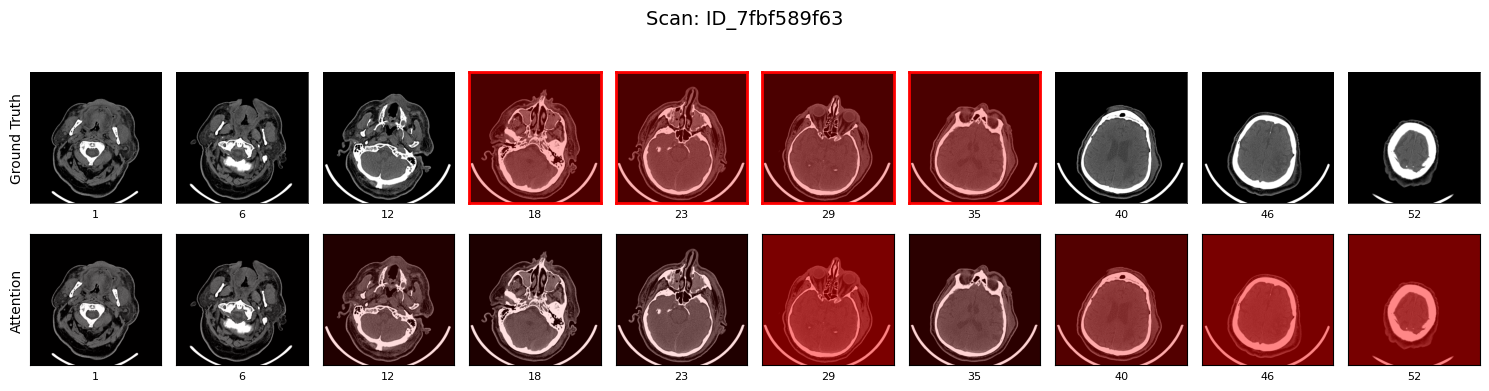

In [10]:
# Load CT slices
ct_data = np.load(f'{numpy_dir}/{scan_id}.npz')['arr_0']  # (1, H, W, S)
ct_slices = ct_data[0].transpose(2, 0, 1)  # (S, H, W)
ct_slices = np.clip(ct_slices, -100, 300)
ct_slices = (ct_slices + 100) / 400

# Sample 10 evenly spaced slices
sample_idx = np.linspace(0, len(labels) - 1, 10, dtype=int)
attn_norm = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i, si in enumerate(sample_idx):
    # Ground truth row
    axes[0, i].imshow(ct_slices[si], cmap='gray')
    if labels[si] == 1:
        axes[0, i].imshow(np.ones((*ct_slices[si].shape, 4)) * [1, 0, 0, 0.3])
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    axes[0, i].set_xlabel(si + 1, fontsize=8)
    for spine in axes[0, i].spines.values():
        spine.set_edgecolor('red' if labels[si] == 1 else 'black')
        spine.set_linewidth(2 if labels[si] == 1 else 0.5)
    
    # Attention row
    axes[1, i].imshow(ct_slices[si], cmap='gray')
    overlay = np.ones((*ct_slices[si].shape, 4)) * [1, 0, 0, attn_norm[si] * 0.5]
    axes[1, i].imshow(overlay)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
    axes[1, i].set_xlabel(si + 1, fontsize=8)

axes[0, 0].set_ylabel('Ground Truth', fontsize=10)
axes[1, 0].set_ylabel('Attention', fontsize=10)
plt.suptitle(f'Scan: {scan_id}', fontsize=14)
plt.tight_layout()
plt.show()

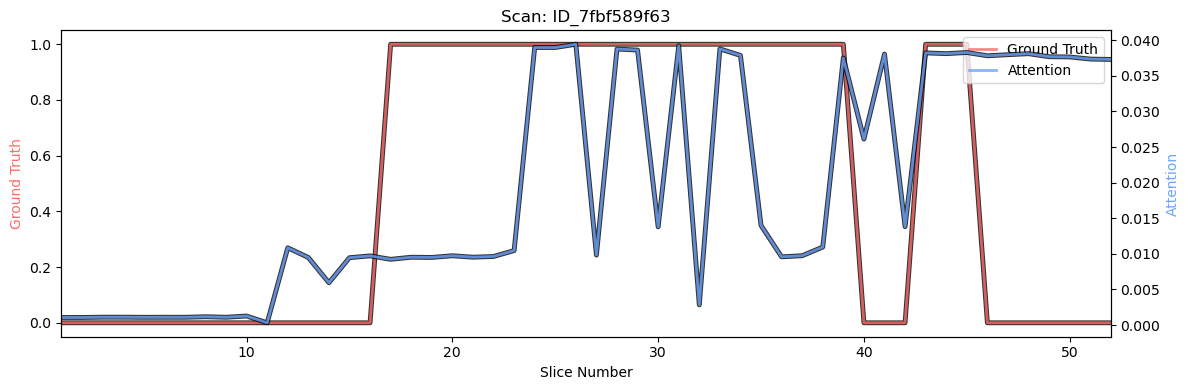

In [11]:
# Line plot
slice_nums = np.arange(1, len(labels) + 1)
gt_color, attn_color = '#FF6B6B', '#6BA3FF'

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(slice_nums, labels, color='black', linewidth=3.5, alpha=0.8)
ax1.plot(slice_nums, labels, color=gt_color, linewidth=2, alpha=0.8, label='Ground Truth')
ax1.set_xlabel('Slice Number')
ax1.set_ylabel('Ground Truth', color=gt_color)
ax1.set_xlim(1, len(labels))
ax1.set_ylim(-0.05, 1.05)

ax2 = ax1.twinx()
ax2.plot(slice_nums, attn, color='black', linewidth=3.5, alpha=0.8)
ax2.plot(slice_nums, attn, color=attn_color, linewidth=2, alpha=0.8, label='Attention')
ax2.set_ylabel('Attention', color=attn_color)
padding = (attn.max() - attn.min()) * 0.05
ax2.set_ylim(attn.min() - padding, attn.max() + padding)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title(f'Scan: {scan_id}')
plt.tight_layout()
plt.show()

## Evaluate Attention Metrics

In [12]:
def evaluate_seed(seed):
    model_path, _ = find_best_model(experiments_dir, pooling, seed)
    test_data = torch.load(f'{dataset_dir}/seed={seed}/test.pth', map_location='cpu', weights_only=False)
    X, lengths, y = test_data['X'], test_data['lengths'], test_data['y']
    
    model = load_model(model_path, X.shape[1], pooling, embedding_level)
    attention = get_attention(model, X, lengths, embedding_level)
    _, slice_labels = get_test_slice_labels(labels_csv, numpy_dir, seed)
    
    attn_sum, aurocs, max_correct = [], [], []
    start = 0
    for i, length in enumerate(lengths):
        attn = attention[start:start + length]
        labels = slice_labels[i]
        start += length
        
        if labels.sum() == 0:
            continue
        
        attn_sum.append(attn[labels == 1].sum())
        if len(np.unique(labels)) > 1:
            aurocs.append(roc_auc_score(labels, attn))
        max_correct.append(labels[np.argmax(attn)] == 1)
    
    return np.mean(attn_sum), np.mean(aurocs), np.mean(max_correct)

results = [evaluate_seed(s) for s in seeds]
results = np.array(results)

print(f"Pooling: {pooling}")
print(f"{'Metric':<30} {'Mean':>10} {'Std':>10}")
print("-" * 50)
for i, name in enumerate(['Attention sum on positive', 'AUROC', 'Max attention correct']):
    print(f"{name:<30} {results[:, i].mean():>10.4f} {results[:, i].std():>10.4f}")

Pooling: ABMIL
Metric                               Mean        Std
--------------------------------------------------
Attention sum on positive          0.4718     0.0085
AUROC                              0.7438     0.0310
Max attention correct              0.6322     0.0929


In [6]:
# Mean pooling baseline: positive_slices / total_slices for each positive bag
def compute_mean_baseline(seed):
    _, slice_labels = get_test_slice_labels(labels_csv, numpy_dir, seed)
    ratios = [labels.sum() / len(labels) for labels in slice_labels if labels.sum() > 0]
    return np.mean(ratios)

baseline_ratios = [compute_mean_baseline(s) for s in seeds]
print("Mean Pooling Baseline (positive_slices / total_slices):")
print(f"  {np.mean(baseline_ratios):.4f} ± {np.std(baseline_ratios):.4f}")
print()
print("This equals:")
print(f"  - attn_sum_on_pos (Mean): {np.mean(baseline_ratios):.4f}")
print(f"  - auroc (Mean): 0.5000 (random)")
print(f"  - max_attn_correct (Mean): {np.mean(baseline_ratios):.4f}")

Mean Pooling Baseline (positive_slices / total_slices):
  0.3625 ± 0.0047

This equals:
  - attn_sum_on_pos (Mean): 0.3625
  - auroc (Mean): 0.5000 (random)
  - max_attn_correct (Mean): 0.3625


In [ ]:
# Plot comparison
slice_nums = np.arange(1, len(labels) + 1)
fig, ax1 = plt.subplots(figsize=(14, 5))

# Ground truth
ax1.plot(slice_nums, labels, color='black', linewidth=3.5, alpha=0.8)
ax1.plot(slice_nums, labels, color='#FF6B6B', linewidth=2, alpha=0.8, label='Ground Truth')
ax1.set_xlabel('Slice Number', fontsize=12)
ax1.set_ylabel('Ground Truth', color='#FF6B6B', fontsize=12)
ax1.set_xlim(1, len(labels))
ax1.set_ylim(-0.05, 1.05)
ax1.tick_params(axis='y', labelcolor='#FF6B6B')

# Attention weights
ax2 = ax1.twinx()
colors = {'ABMIL': '#4A90E2', 'TransMIL': '#50C878', 'SmAP': '#9B59B6'}

for method, attn in attentions.items():
    attn_norm = (attn - attn.min()) / (attn.max() - attn.min())
    ax2.plot(slice_nums, attn_norm, color=colors[method], linewidth=2, alpha=0.7, label=method)

ax2.set_ylabel('Normalized Attention', fontsize=12)
ax2.set_ylim(-0.05, 1.05)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.title(f'Attention Comparison - Scan: {scan_id_target}', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Compare ABMIL, TransMIL, and SmAP on the same scan
seed = 1001
scan_id_target = 'ID_7fbf589f63'

# Load data
test_data = torch.load(f'{dataset_dir}/seed={seed}/test.pth', map_location='cpu', weights_only=False)
X, lengths, y = test_data['X'], test_data['lengths'], test_data['y']
scan_ids, slice_labels = get_test_slice_labels(labels_csv, numpy_dir, seed)

# Find target scan
idx = np.where(scan_ids == scan_id_target)[0][0]
labels = slice_labels[idx]
start = sum(lengths[:idx])
length = lengths[idx]

# Get attention for each method
attentions = {}
for method in ['ABMIL', 'TransMIL', 'SmAP']:
    model_path, _ = find_best_model(experiments_dir, method, seed)
    if model_path:
        model = load_model(model_path, X.shape[1], method, embedding_level)
        attention = get_attention(model, X, lengths, embedding_level)
        attentions[method] = attention[start:start + length]
        print(f"{method}: loaded")
    else:
        print(f"{method}: not found")

print(f"\nScan: {scan_id_target}, {len(labels)} slices, {labels.sum()} positive")

## Compare All Methods on Same Scan